In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import subprocess
from tqdm import tqdm_notebook
import pprint
import librosa
from IPython.display import clear_output
from scipy.ndimage import convolve
import music21
import madmom
from scipy.signal import convolve2d
from scipy.stats import linregress
from multiprocessing import Pool
import yaml
import pickle

from msmd.midi_parser import notes_to_onsets, FPS
from msmd.data_model.piece import Piece
from msmd.alignments import align_score_to_performance

In [3]:
DATA_ROOT_REAL = '../real_dataset'

In [4]:
pieces = glob.glob(os.path.join(DATA_ROOT_REAL, 'pickle', '*'))

In [5]:
def fitStaffLines(scores, height):
    N = len(scores)
    idx_RH, idx_LH, best_score = 0, 0, -1
    idxs_sorted = np.argsort(scores)[::-1]
    min_separation = int(height * 1.66)
    idx1 = idxs_sorted[0]
    for j in range(1, N):
        idx2 = idxs_sorted[j]
        curScore = scores[idx1] + scores[idx2]
        sep = np.abs(idx1 - idx2)
        if sep > min_separation and curScore > best_score:
            best_score = curScore
            idx_RH = min(idx1, idx2)
            idx_LH = max(idx1, idx2)
            break
    return best_score, idx_RH, idx_LH

def locateStaffLines(s, min_height = 5, max_height = 50, plot = True):
    rsums = np.sum(s, axis=1)
    bestScore = 0
    lineLocs = np.zeros(10)
    for h in range(min_height,max_height+1):
        idxs = h * np.arange(5) / 4.0
        idxs = idxs.round().astype('int')
        filt = np.zeros(h+1)
        filt[idxs] = 1 # create comb filter
        scores = np.convolve(rsums, filt, 'valid')
        curScore, idx_RH, idx_LH = fitStaffLines(scores, h)
        if curScore > bestScore:
            bestScore = curScore
            lineLocs[0:5] = idxs + idx_RH
            lineLocs[5:] = idxs + idx_LH
    
    if plot:
        plt.plot(rsums)
        for i in range(len(lineLocs)):
            plt.axvline(x=lineLocs[i], color='r', linewidth=1)
        plt.show()
        
    return lineLocs

In [6]:
def ReLU(x):
    return x * (x > 0)

def computeOnsetLikelihood(spectrogram):
    """
    Compute onset likelihood based on the given spectrogram
    """
    output = np.zeros_like(spectrogram)
    output[:,0] = spectrogram[:,0]
    output[:,1:] = ReLU(spectrogram[:,1:] - spectrogram[:,:-1])

    mv_mean = convolve(output, np.ones((1,5))/5, mode='constant')
    smoothed = ReLU(output - mv_mean)
    return smoothed

In [7]:
def estimateMidiNum2PixelRowMapping(s, lineIdxs, hand = 'right'):
    if hand == 'right':
        x = np.array([77, 74, 71, 67, 64]) # midi nums for staff lines
    elif hand == 'left':
        x = np.array([57, 53, 50, 47, 43])
    else:
        print('Unrecognized value for hand: %s' % hand)
        sys.exit(1)
    m, b, _, _, _ = linregress(x, lineIdxs)
    return (m,b)

def estimatePixelRow(midinum, m, b):
    return np.int(np.round(midinum * m + b))

def generateNoteImpulses(onset_spec, strip, m, b, total_length):
    factor = int(np.ceil(total_length / onset_spec.shape[1]))
    synthLen = factor * onset_spec.shape[1]
    impulses = np.zeros((strip.shape[0], synthLen))
    
    for r in range(onset_spec.shape[0]):
        MIDI_num = r + 21
        row = estimatePixelRow(MIDI_num, m, b)
        for timeIdx in range(0,onset_spec.shape[1]):
            if row >= 0 and row < strip.shape[0]:
                impulses[row, factor * timeIdx] = (onset_spec[r, timeIdx] / np.max(onset_spec)) ** 2
    return impulses

def adjustMidiTiming(noteImpulses, maxPauseLen = 50):
    
    # identify long pauses where no onsets occur
    csums = np.sum(noteImpulses, axis=0)   
    dataToInsert = [] # either the index of the column to insert, or -1 for a column of zeros
    isPause = False
    markerStart = 0
    for i in range(len(csums)):
        if isPause:
            if csums[i] != 0 or i == len(csums) - 1: # in a pause, notes occur
                pauseLen = i - markerStart
                if pauseLen > maxPauseLen:
                    dataToInsert.extend([-1] * maxPauseLen)
                else:
                    dataToInsert.extend([-1] * pauseLen)
                dataToInsert.append(i)
                isPause = False
            else: # in a pause, no notes occur
                pass
        else:
            if csums[i] != 0: # not a pause, notes occur
                dataToInsert.append(i)
            else: # not a pause, no notes occur
                isPause = True
                markerStart = i
    
    # reconstruct onset data
    adjusted = np.zeros_like(noteImpulses)
    # Original:    adjusted = np.zeros((noteImpulses.shape[0],len(dataToInsert)))
    for i, col in enumerate(dataToInsert):
        if col == -1:
            pass # leave as zeros
        else:
            adjusted[:,i] = noteImpulses[:,col]
    return adjusted, dataToInsert

def zeroPadColumns(X, nBefore, nAfter):
    h = X.shape[0]
    Y = np.hstack((np.zeros((h,nBefore)), X, np.zeros((h,nAfter))))
    return Y

def get2DFilter(m):
    filt_sz = np.int(np.round(np.abs(m) * 4))
    filt2d = getBlurFilter(filt_sz, 'block')
    return filt2d

def getBlurFilter(sz, filterType):
    if filterType == 'hamming':
        filt = np.matmul(np.hamming(sz).reshape((sz,1)), np.hamming(sz).reshape(1,sz))
    elif filterType == 'circle':
        filt = np.zeros((sz,sz))
        center = sz/2
        for i in range(sz):
            for j in range(sz):
                if np.sqrt((i-center)*(i-center)+(j-center)*(j-center)) <= center - .01:
                    filt[i,j] = 1
    elif filterType == 'block':
        filt = np.ones((np.int(1.2*sz),np.int(1.125*sz)))
    else:
        print('Unrecognized filter type: %s' % filterType)
        sys.exit(1)
    return filt

In [8]:
def generateBootleg(piece_idx, debug=False):
    piece = os.path.split(pieces[piece_idx])[1]
    
    # Load strips
    strips = None
    with open(os.path.join(DATA_ROOT_REAL, 'pickle', piece), 'rb') as f:
        strips = pickle.load(f)
        
    # Convert color strips
    for i in range(len(strips)):
        strips[i] = 255 * (1 - strips[i])
        
    # Extract staff lines
    staff_lines = []
    for strip in strips:
        lines = locateStaffLines(255 - strip, min_height=20, max_height=50, plot=False)
        staff_lines.append(lines)   

    # Load spectrogram
    spec_file = os.path.join(DATA_ROOT_REAL, 'spec', '_'.join(piece.split('_')[:-1]) + '_spec.npy')
    spec = np.load(spec_file)
    
    if debug:
        print("spec.shape = {} {}".format(spec_file, spec.shape))
        plt.imshow(spec, aspect='auto', cmap='hot')
        plt.show()
        

    # Compute salience representation
    # Construct a summing filter at 8 harmonic locations
    filt = np.zeros((spec.shape[0],1))
    filt[np.round(12 * np.log2(np.arange(1,8))).astype(np.int)] = 1

    # Compute the harmonic summation
    spec = np.flipud(convolve2d(np.flipud(spec), filt, mode='full'))[spec.shape[0]-1:]


    onsets = computeOnsetLikelihood(spec)
    if debug:
        print("onsets.shape = {}".format(onsets.shape))
        plt.imshow(onsets, aspect='auto', cmap='hot')
        plt.colorbar()
        plt.show()
    
    
    # analyze the strip
    total_length = sum(list(map(lambda x: x.shape[1], strips)))

    # Create bootleg for each strip
    Cblocks = []
    synths = []
    zeroPad = 50
      
    if debug:
        for strip in strips:
            plt.imshow(strip, cmap='gray')
            plt.show()
    
    timeMapping = None
    for k in tqdm_notebook(range(len(strips))):
        strip = 255 - strips[k]
        lines = staff_lines[k]
        breakpt = np.int(np.round(.5 * (lines[4] + lines[5])))
        upper = strip[0:breakpt, :]
        lower = strip[breakpt:, :]
        m1, b1 = estimateMidiNum2PixelRowMapping(upper, lines[0:5], 'right')
        m2, b2 = estimateMidiNum2PixelRowMapping(lower, lines[5:10] - breakpt, 'left')

        # synthesis
        impulses1 = generateNoteImpulses(onsets, upper, m1, b1, total_length)
        impulses2 = generateNoteImpulses(onsets, lower, m2, b2, total_length)
        impulses = np.vstack((impulses1, impulses2))
        timeAdjusted, timeMapping = adjustMidiTiming(impulses)
        zeroPadded = zeroPadColumns(timeAdjusted, zeroPad, zeroPad)
        filt2d = get2DFilter(np.mean([np.abs(m1),np.abs(m2)]))    
        blurred = convolve2d(zeroPadded, filt2d, 'same')
        stavesTemplate = np.matlib.repmat(np.median(strip, axis=1).reshape(-1,1), 1, blurred.shape[1])
        withLines = np.clip(blurred, 0, 1)
        synths.append(withLines)

        s1 = strip
        s2 = withLines
        costBlock = -1.0 * np.matmul(s1.T, s2)
        Cblocks.append(costBlock)
    
    C = np.vstack(Cblocks)
    
    # DTW
    steps = np.array([1,1,1,2,2,1]).reshape((-1,2))
    weights = np.array([2,3,3])
    D, wp = librosa.core.dtw(C=C, step_sizes_sigma=steps, weights_mul=weights, subseq=False)
    wp = wp[::-1,:]
    
    # output
    output = {}
    output['wp'] = wp
    output['striplens'] = [s.shape[1] for s in strips]
    output['zeroPad'] = zeroPad
    output['timeMapping'] = timeMapping
    output['factor'] = (C.shape[1] - 2*zeroPad) // spec.shape[1]

    if not os.path.exists(os.path.join(DATA_ROOT_REAL, 'output')):
        os.mkdir(os.path.join(DATA_ROOT_REAL, 'output'))
        
    if not os.path.exists(os.path.join(DATA_ROOT_REAL, 'output', piece)):
        os.mkdir(os.path.join(DATA_ROOT_REAL, 'output', piece))
    
    output_file_path = os.path.join(DATA_ROOT_REAL, 'output', piece, 'output.npy')
    np.save(output_file_path, output)
    
    # Visualize
    if debug:
        maxH = np.max([s.shape[0] for s in strips])
        pan1 = np.zeros((maxH, wp.shape[0]))
        cumStripLens = np.cumsum([0] + [s.shape[1] for s in strips])
        print(len(strips), cumStripLens)
        col2strip = [i for i, s in enumerate(strips) for j in range(s.shape[1])] # column index -> strip index
        print(wp)
        for i in range(wp.shape[0]):
            globalIdx = wp[i,0]
            stripIdx = col2strip[globalIdx]
            h = strips[stripIdx].shape[0]
            localIdx = globalIdx - cumStripLens[stripIdx]
            pan1[0:h,i] = strips[stripIdx][:, localIdx] /255
        pan2 = np.zeros((maxH, wp.shape[0]))
        for i in range(wp.shape[0]):
            sheetColIdx = wp[i,0]
            midiColIdx = wp[i,1]
            stripIdx = col2strip[sheetColIdx]
            h = synths[stripIdx].shape[0]
            pan2[0:h, i] = synths[stripIdx][:,midiColIdx]
        plt.figure(figsize=(20,10))
        plt.imshow(np.vstack((pan1[:,:1500], 1 - pan2[:,:1500])), aspect='auto', cmap='gray')
        plt.show()
        
        output_file_path = os.path.join(DATA_ROOT_REAL, 'output', piece, 'pan1.npy')
        np.save(output_file_path, pan1)
        output_file_path = os.path.join(DATA_ROOT_REAL, 'output', piece, 'pan2.npy')
        np.save(output_file_path, pan2)

spec.shape = ../real_dataset/spec/clementi_op36no1mv3_spec.npy (88, 1132)


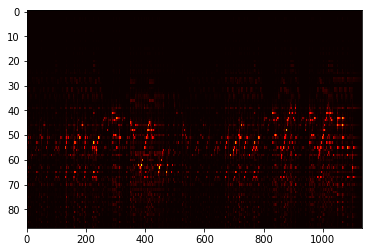

onsets.shape = (88, 1132)


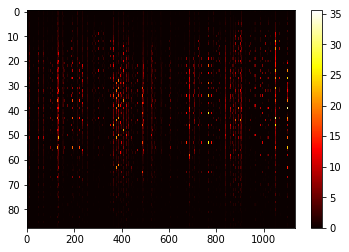

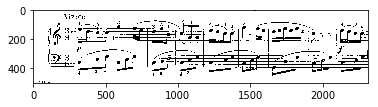

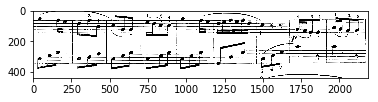

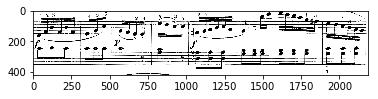

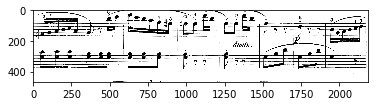

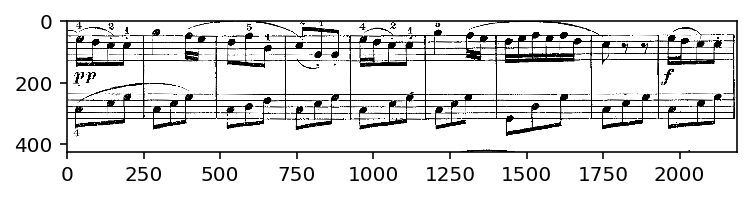

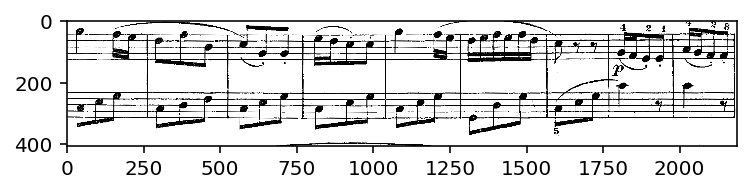

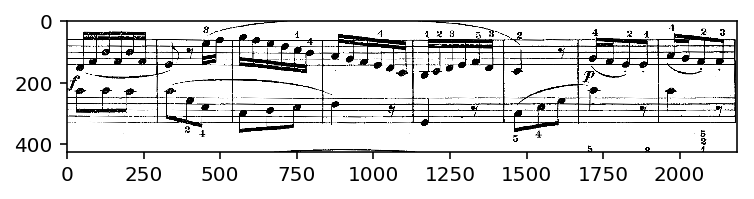

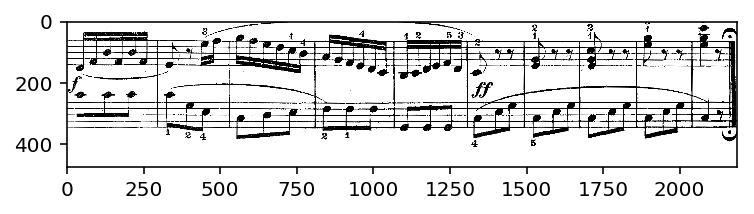

HBox(children=(IntProgress(value=0, max=8), HTML(value='')))


8 [    0  2313  4499  6685  8871 11057 13243 15429 17615]
[[    0     0]
 [    2     1]
 [    4     2]
 ...
 [17612 18208]
 [17613 18210]
 [17614 18211]]


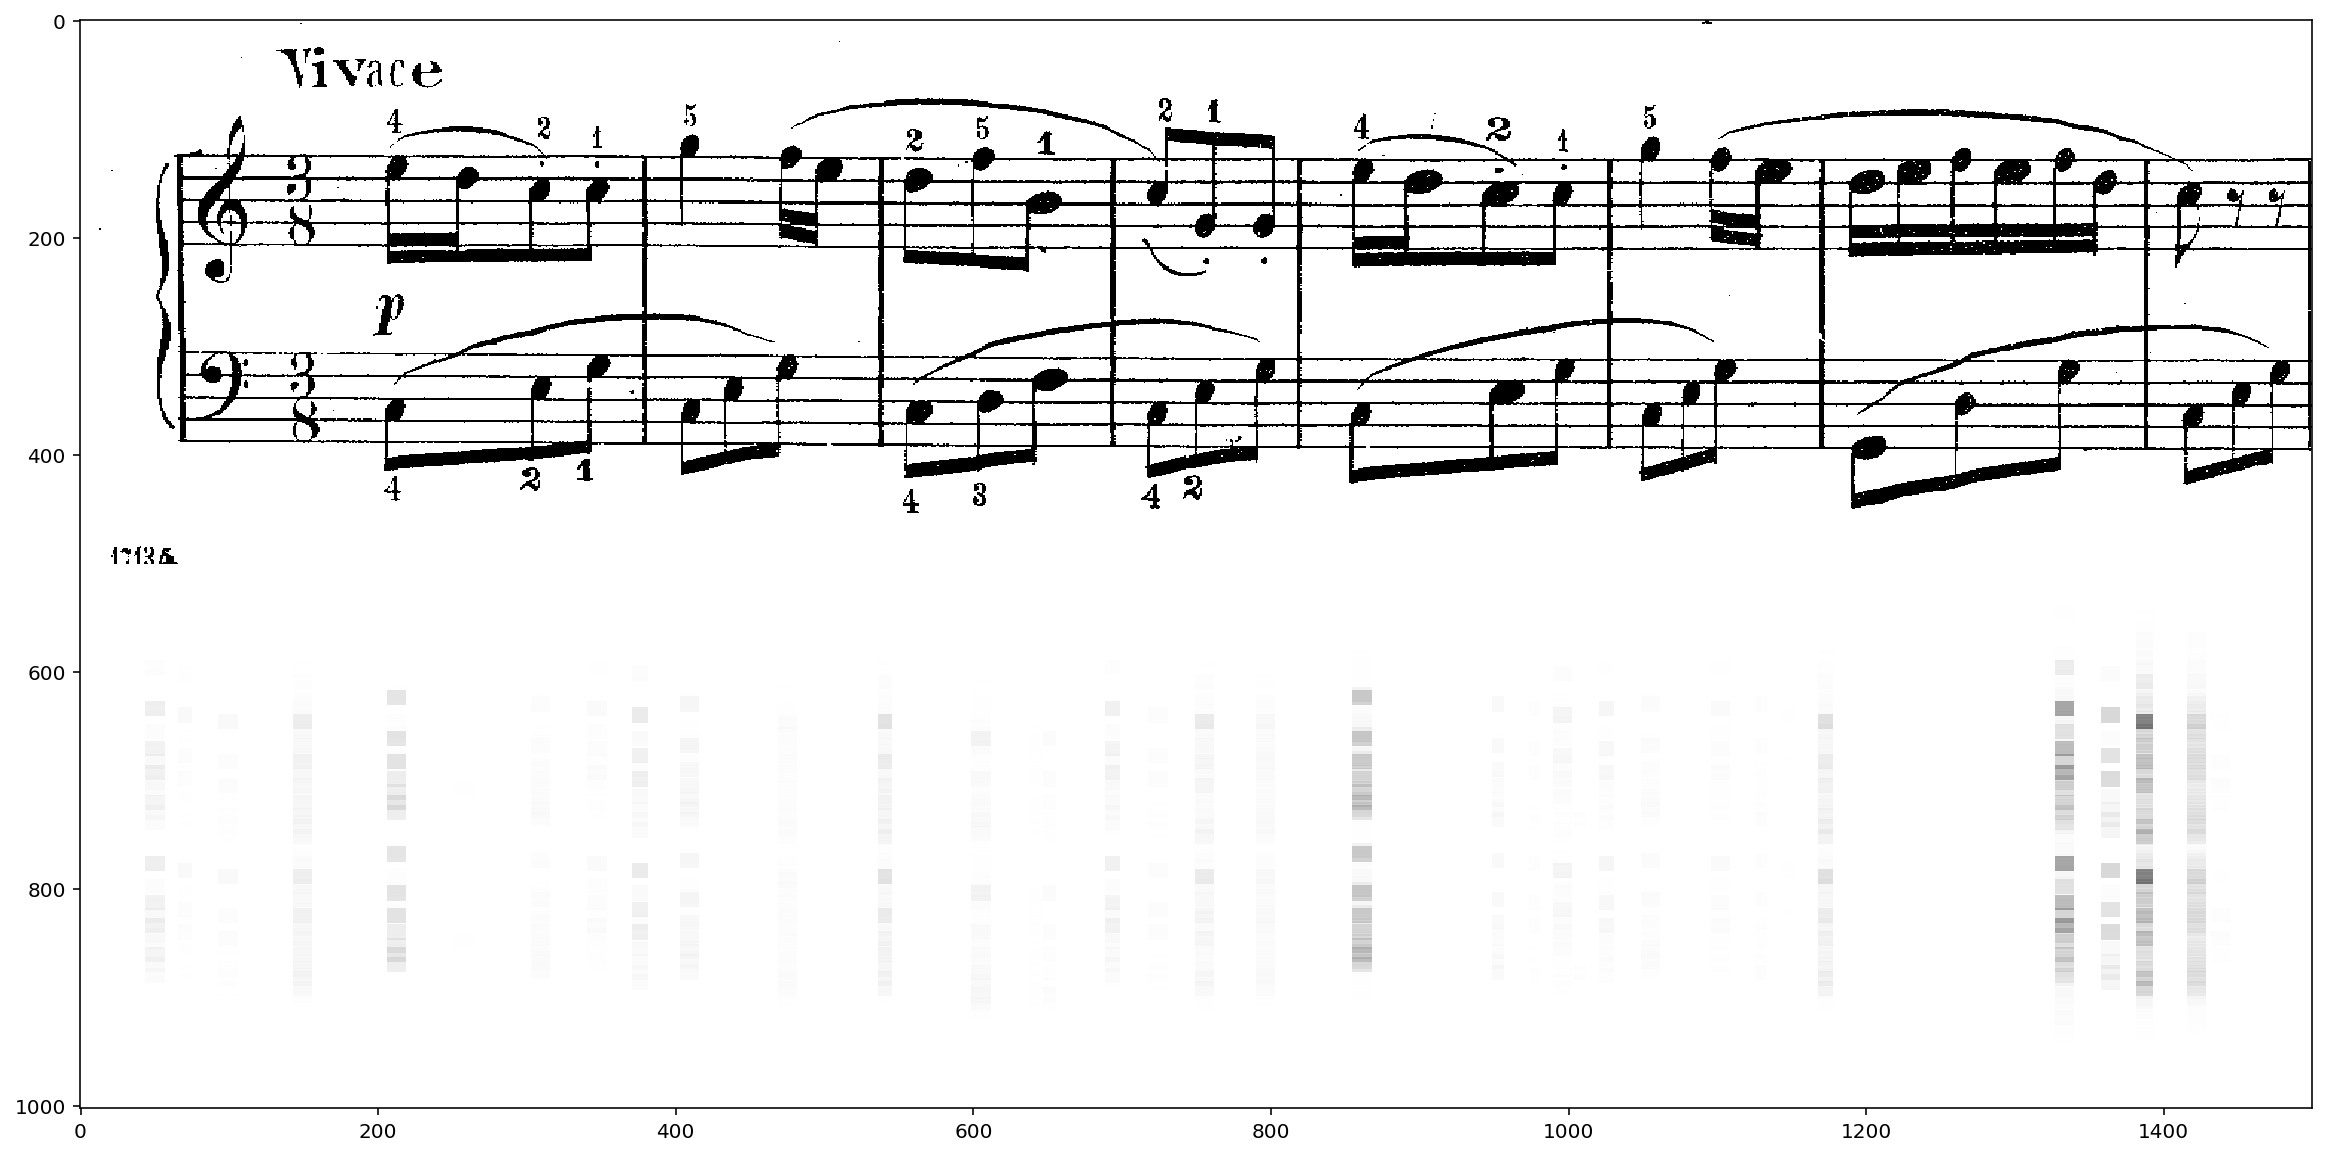

In [9]:
generateBootleg(0, debug=True)

In [10]:
for i in tqdm_notebook(range(len(pieces))):
    generateBootleg(i, debug=True)
    
# with Pool(12) as p:
#     list(tqdm_notebook(p.imap(generateBootleg, range(len(pieces))), total=len(pieces)))

HBox(children=(IntProgress(value=0, max=69), HTML(value='')))

HBox(children=(IntProgress(value=0, max=8), HTML(value='')))

HBox(children=(IntProgress(value=0, max=10), HTML(value='')))

HBox(children=(IntProgress(value=0, max=11), HTML(value='')))

HBox(children=(IntProgress(value=0, max=10), HTML(value='')))

HBox(children=(IntProgress(value=0, max=10), HTML(value='')))

HBox(children=(IntProgress(value=0, max=14), HTML(value='')))

HBox(children=(IntProgress(value=0, max=20), HTML(value='')))

MemoryError: 